In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/MarvinAntillon97/CasoPractico/refs/heads/main/Archivo/Prestige_modificado.csv", sep=';')
df.head()



,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


In [7]:
print(df.shape)
print(df.columns)
print(df.info())


(102, 7)
Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [8]:
print(df.isnull().sum())

occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df.describe())

        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  
std      0.817447  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      2.000000  
max      3.000000  


In [19]:
variables_numericas = [
    'education',
    'income',
    'women',
    'prestige',
    'census',
    'type_num'
]

for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(columna, len(atipicos))

education 0
income 4
women 6
prestige 3
census 0
type_num 4


In [20]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])

matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000


In [22]:
print(
    matriz_correlacion['prestige']
    .sort_values(ascending=False)
    .round(3)
)

prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


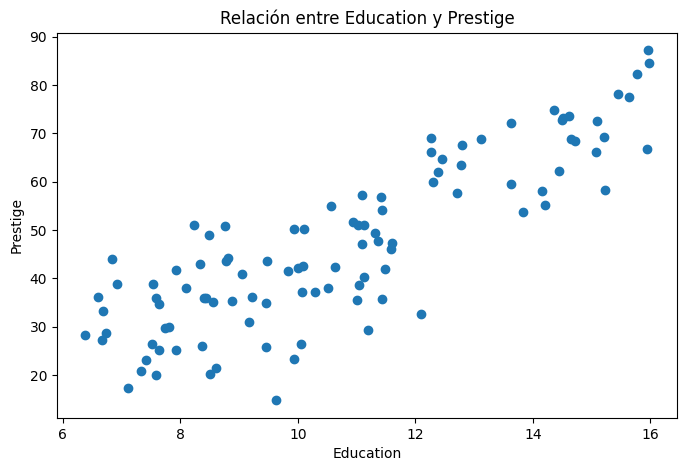

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df['education'], df['prestige'])

plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Relación entre Education y Prestige')

plt.show()

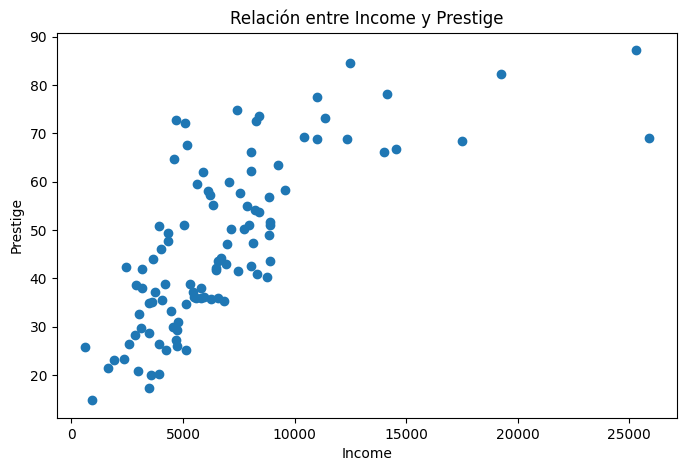

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df['income'], df['prestige'])

plt.xlabel('Income')
plt.ylabel('Prestige')
plt.title('Relación entre Income y Prestige')

plt.show()

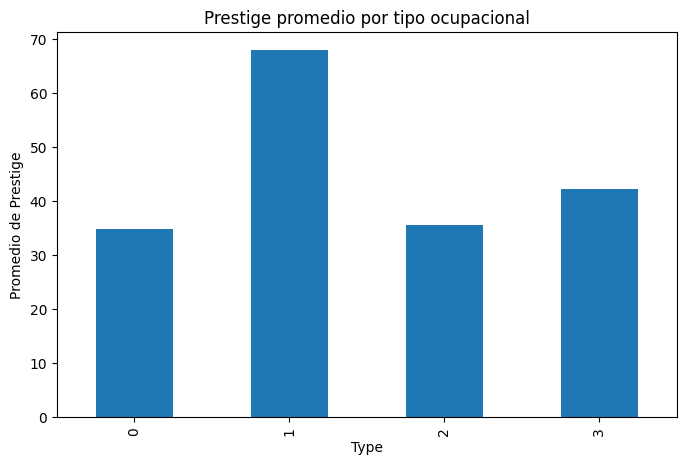

In [30]:
plt.figure(figsize=(8,5))

df.groupby('type_num')['prestige'].mean().plot(kind='bar')

plt.xlabel('Type')
plt.ylabel('Promedio de Prestige')
plt.title('Prestige promedio por tipo ocupacional')

plt.show()

In [34]:
columnas_cluster = [
    'education',
    'income',
    'women',
    'prestige',
    'type_num'
]

X = df[columnas_cluster].copy()

escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)

In [35]:
modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

print(
    df.groupby('Cluster_4')[columnas_cluster]
    .mean()
    .round(2)
)


           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00


In [36]:
modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(
    df.groupby('Cluster_5')[columnas_cluster]
    .mean()
    .round(2)
)


           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00
